In [23]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [5]:
load_dotenv()

True

In [6]:
Generator_OpenAI_Model = ChatOpenAI(model="gpt-5.4-mini", temperature=0.7)
Evaluator_OpenAI_Model = ChatOpenAI(model="gpt-5.4-mini", temperature=0.7)
Optimizer_OpenAI_Model = ChatOpenAI(model="gpt-5.4-mini", temperature=0.7)

In [7]:
Generator_Gemini_Model = ChatGoogleGenerativeAI( model="gemini-3.1-flash-lite" )
Evaluator_Gemini_Model = ChatGoogleGenerativeAI( model="gemini-3.1-flash-lite" )
Optimizer_Gemini_Model = ChatGoogleGenerativeAI( model="gemini-3.1-flash-lite" )

In [ ]:
# State
class TweetState(TypedDict):
    
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iterations: int
    
    tweet_history: Annotated[list[str], operator.add]  # This will collect the tweets generated in each iteration
    tweet_feedback_history: Annotated[list[str], operator.add]  # This will collect the feedback received in each iteration

In [9]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final Evaluation")
    feedback: str = Field(..., description="Feedback for the tweet.")

In [10]:
structured_evaluator_llm = Evaluator_Gemini_Model.with_structured_output(TweetEvaluation)

In [ ]:
def generate_tweet(state: TweetState):
    
        # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """)
    ]
    
    # Send Generator Model
    response = Generator_Gemini_Model.invoke(messages).content
    
    return {'tweet': response, 'tweet_history': [response]}

In [ ]:
def evaluate_tweet(state: TweetState):
    
    # Prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
    ]
    
    # Evaluation
    response = structured_evaluator_llm.invoke(messages)
    
    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'tweet_feedback_history': response.feedback}

In [ ]:
def optimize_tweet(state: TweetState):
    
    # Prompt
    messages = [
        SystemMessage(content="You are a witty and clever Twitter/X influencer. You are tasked with improving tweets based on feedback."),
        HumanMessage(content=f"""
            Improve the following tweet based on the feedback provided:

            Topic: "{state['topic']}"
            Tweet: "{state['tweet']}"
            Feedback: "{state['feedback']}"

            Rules:
            - Keep it under 280 characters.
            - Maintain the original topic and intent.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Avoid generic or throwaway lines.
            """)
    ]


    # Send to Optimizer Model
    reponse = Optimizer_Gemini_Model.invoke(messages).content
    iteration = state['iteration'] + 1
    
    return {'tweet': reponse, 'iteration': iteration, 'tweet_history': [response]}

In [14]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvement'

In [15]:
graph = StateGraph(TweetState)

# Nodes
graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

# Edges
graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')

graph.add_conditional_edges('evaluate_tweet', route_evaluation, {'approved': END, 'needs_improvement': 'optimize_tweet'})
graph.add_edge('optimize_tweet', 'evaluate_tweet')

workflow = graph.compile()

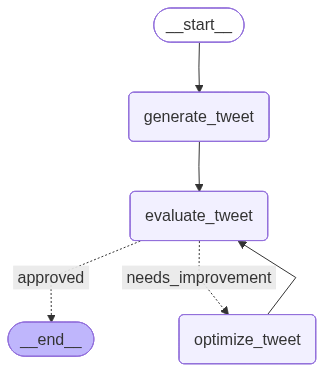

In [16]:
workflow

In [20]:
initial_state = {
    'topic': 'Started Learning Redis',
    'iteration': 1,
    'max_iterations': 3
}

workflow.invoke(initial_state)

{'topic': 'Started Learning Redis',
 'tweet': [{'type': 'text',
   'text': 'Started learning Redis today. It’s basically just keeping a post-it note on your forehead that says "I WILL FORGET THIS IN 30 MINUTES" and calling it an architecture pattern. 🧠💨 #coding #redis',
   'extras': {'signature': 'EjQKMgEMOdbHYGPG+ne4v+ekLH1KbXJKlBjsFT8TBzwr96Kmd4pr9LCzZjH+zD2z9gypD/d3'}}],
 'evaluation': 'approved',
 'feedback': 'This tweet effectively utilizes relatable developer pain points and a strong, visual metaphor to poke fun at technical concepts. It avoids the tired setup-punchline structure in favor of a punchy, observational style that resonates with the target audience. The tone is cynical enough to be authentic, and the brevity keeps the engagement high, making it prime bait for the tech-Twitter algorithm.',
 'iteration': 1,
 'max_iterations': 3}